<a href="https://colab.research.google.com/github/michx02/-Friend-Bot--Project/blob/main/mmc10050_6_PA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Neural Networks

**For training Tensorflow models, you should connect to a Colab runtime with GPU to make training much faster**


This part involves building and evaluating neural network models for image classification using the CIFAR-10 dataset. The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 different classes, such as airplanes, cars, birds, and more. In this assignment, we will first use a vanilla neural network to classify these images and later compare its performance to a more specialized model, a Convolutional Neural Network (CNN), which is better suited for handling image data.

**The images are of shape (32, 32, 3), where 32x32 is the resolution and 3 represents the RGB color channels.**

If you are curious how about accurate models are on this dataset, check out this [benchmark](https://paperswithcode.com/sota/image-classification-on-cifar-10)

**Learning Objectives:**

1. Understand the challenges of using a MLP neural network for image classification tasks.

2. Gain practical experience in training a convolutional neural network (CNN) for image classification.

3. Compare the effectiveness of different neural network architectures for computer vision tasks.



In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from typing import Tuple
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load dataset

In this function, we will load the CIFAR-10 dataset, normalize it, and one-hot encode the labels.

In [2]:
def load_and_preprocess_data() -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Load and preprocess the CIFAR-10 dataset.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]: Training and test sets, both inputs and targets as NumPy arrays.
    """
    # Load the CIFAR-10 dataset
    (X_train, y_train), (X_test, y_test) = cifar10.load_data()

    # Normalize the features
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # One-hot encode the target labels
    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)

    return X_train, X_test, y_train, y_test

# Visualize dataset

This function will help us visualize a few images from the dataset before starting to build the models.


In [3]:
def visualize_images(X: np.ndarray, y: np.ndarray, class_names: list[str], num_images: int = 10) -> None:
    """
    Display a few sample images from the dataset.

    Args:
        X (np.ndarray): Image data.
        y (np.ndarray): Corresponding labels.
        class_names (list[str]): List of class names.
        num_images (int, optional): Number of images to display. Defaults to 10.
    """
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 5))
    for i in range(num_images):
        plt.subplot(2, 5, i + 1)
        plt.imshow(X[i])
        plt.title(class_names[np.argmax(y[i])])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


# MLP neural network model [15 points + 5 Bonus]

You should take a look at the tensorflow guides on how to create a MLP using tensorflow.

Set up the layers
The basic building block of a neural network is the [layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers). Layers extract representations from the data fed into them. Hopefully, these representations are meaningful for the problem at hand.

Most of deep learning consists of chaining together simple layers. Most layers, such as tf.keras.layers.Dense, have parameters that are learned during training.

1. Create a Sequential model.
2. Add a [Flatten](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten) layer to convert image data into a 1D vector.
3. Add two [Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) layers with ReLU activation.
4. Add a Dense output layer with softmax activation for classification.
5. Compile the model using [Adam optimizer](https://keras.io/api/optimizers/adam/), categorical crossentropy loss, and accuracy metric.

Adam is variant of SGD that we studied in class.

categorical crossentropy loss is an extension of the crossentropy loss from logistic regression to multiple categories. [Here](https://www.tensorflow.org/api_docs/python/tf/keras/losses) is a list of different kind of losses that tensorflow implements.

## Define function to create MLP model [7 points]

In [ ]:
def create_mlp_model(input_shape: int) -> tf.keras.Model:
    """
    Create and compile a MLP neural network model.

    Args:
        input_shape (int): The number of input features.

    Returns:
        tf.keras.Model: Compiled TensorFlow model.

    Detailed Notes:
        This function creates a fully connected (vanilla) neural network model:
        1. Input Layer: Flatten the input images into a 1D vector.
        2. Hidden Layers:
            - First hidden layer with 512 units and ReLU activation function.
            - Second hidden layer with 256 units and ReLU activation function.
        3. Output Layer: 10 units (for 10 classes) with softmax activation for classification.
        The model is compiled using the Adam optimizer, Categorical Crossentropy as the loss function,
        and Accuracy as the evaluation metric.
    """
    # fill code here

    return model

Now lets run this model and see what kind of accuracy we get.

Remember, a MLP neural network takes in a 1D array. Images are 2D arrays, so you need to first convert them into 1D representation.


In [ ]:
# first load the data


In [ ]:
# Define class names for CIFAR-10 dataset
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

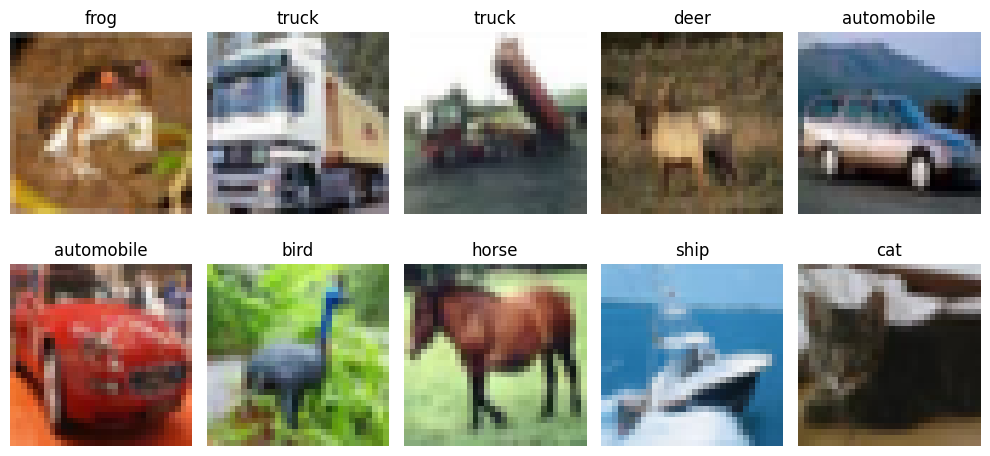

In [ ]:
visualize_images(X_train, y_train, class_names)

### Gradient Descent Refresher

**Epoch**

An epoch is one complete pass through the entire training dataset. During an epoch, the model sees every sample in the training set once, processes it, and updates its weights based on the error calculated from predictions.

Typically, neural networks are trained for multiple epochs, allowing the model to refine its weights gradually.

**Example:**

Suppose you have a dataset with 10,000 training samples, and you train your model for 10 epochs. This means that during training:


*   The model will process the entire dataset 10 times.
*   Each epoch involves making predictions on all 10,000 samples and updating the weights accordingly.

**Batch Size**

The batch size is the number of training samples processed before the model updates its weights. Instead of updating the model after every single training sample (which can be slow and computationally expensive), the data is split into smaller groups called batches.

**Example:**

If you have a dataset of 1,000 samples and set the batch size to 100:
The dataset is split into 10 batches (1,000 / 100 = 10).
The model processes each batch separately, makes predictions, calculates the loss, and updates the weights.
Once all 10 batches are processed, it completes 1 epoch.


**How does this connect to Gradient Descent?**

There are three types of gradient descent:

**Batch Gradient Descent:**

The batch size is equal to the entire dataset (e.g., 10,000 samples in a single batch).
The model updates its weights only once per epoch.
It is computationally expensive for large datasets.

**Stochastic Gradient Descent (SGD):**

The batch size is set to 1 (i.e., the model updates its weights after every single sample).
It is fast but can be noisy, as each update is based on a single sample.


**Mini-Batch Gradient Descent (Most Common):**

The batch size is set to a value between 1 and the size of the entire dataset (e.g., 32, 64, 128).
It strikes a balance between the efficiency of Batch Gradient Descent and the noise reduction of SGD.


## Run the MLP neural network [8 points]

In [ ]:
# fill code to run the MLP and print out the test accuracy

##Bonus [5 points]

As you can see the accuracy is pretty bad (~50%). Can you get an accuracy of at least 55% on the test set?

Briefly explain what you did to get credit.

# Convolution Neural Networks [24 points + 5 bonus]

As we saw above, MLPs are not that great when it comes to image classification tasks. Can we do better?

## Why Do We Need CNNs?

In MLPs, every neuron is connected to every other neuron in the next layer, which works well for simple, flattened data. However, image data is **spatially structured**, meaning the spatial relationships between pixels are important. If we flatten the image (e.g., a 28x28 image becomes a 784-length vector), we lose this spatial information.

**Key Limitations of MLPs for Image Data:**
- The input size grows significantly as the image resolution increases.
- MLPs treat every pixel independently and ignore spatial relationships.

**CNNs address these issues** by using convolution operations that preserve the spatial structure of the data, making them more efficient and effective for image analysis.

## Key Layers in a CNN

1. **Convolution Layer:** Applies convolution operations using a set of filters.
2. **Activation Function (ReLU):** Applies the ReLU activation to add non-linearity.
3. **Pooling Layer (Max Pooling):** Reduces the spatial dimensions while retaining important features.
4. **Fully Connected Layer:** Flattens the data and applies a standard dense layer as in MLPs.

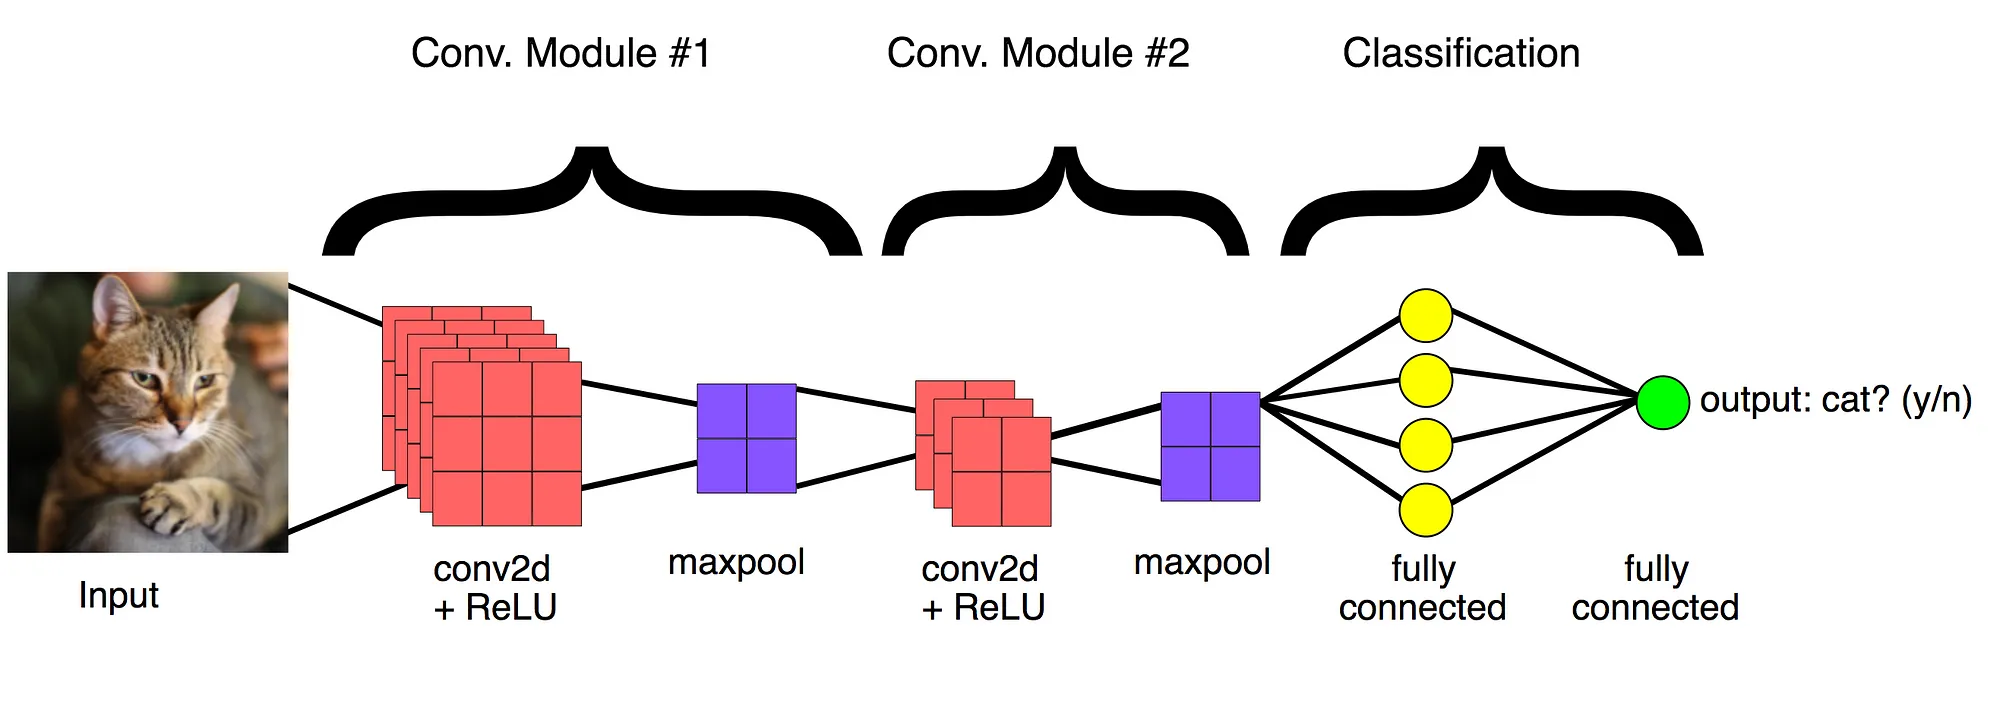

##Convolution Operation: The Core of CNNs

A **convolution** is a mathematical operation that slides a filter (or kernel) over an input image to extract certain features.

**Key Concepts**

- **Filter (Kernel):** A small matrix that we slide over the input image. The filter's size is typically smaller than the input (e.g., 3x3 or 5x5).
- **Stride:** The step size of the filter as it moves across the image.
- **Padding:** Adding extra pixels around the input image to control the output size.

**How Does It Work?**

At each step, the filter matrix is multiplied element-wise with the part of the image it overlaps, and the results are summed up to produce a single number. This number forms the output of the convolution at that position.

Mathematically, if `X` is the input image and `K` is the filter:
$$
Y(i, j) = \sum_{m=0}^{h-1} \sum_{n=0}^{w-1} X(i+m, j+n) \cdot K(m, n)
$$

Where:
- $h$ and $w$ are the height and width of the filter.
- $i$ and $j$ are the coordinates of the top-left corner of the current region of the image being considered.


**Example:**
- **Input Image (5x5 matrix):** Imagine this is a small grayscale image where each value represents the pixel intensity.
- **Filter (Kernel 3x3):** This is a simple filter we will slide across the image.

**How It Works:**

1. We overlay the filter on the top-left corner of the image.
2. We perform an element-wise multiplication between the filter and the overlapping part of the image.
3. We sum up the results of the multiplication to get a single value.
4. We move the filter to the next position (based on the stride) and repeat.

Let's see this in action using Python code.

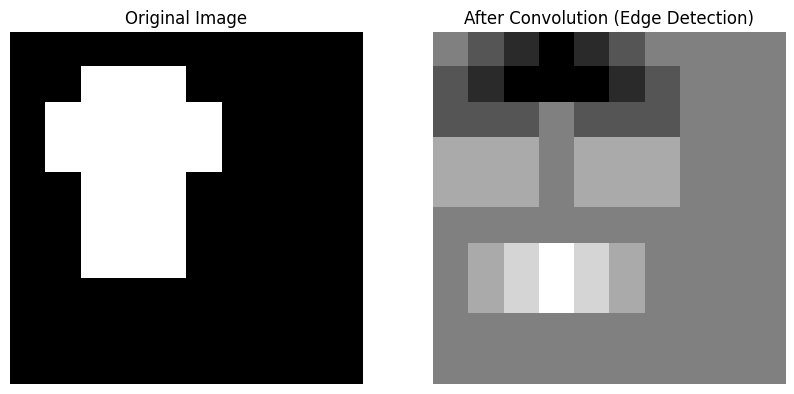

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# Create a simple grayscale image (10x10 matrix)
image = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

# Define a simple edge detection filter (3x3 Sobel filter)
filter = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
])

# Apply the convolution operation
convolved_image = convolve(image, filter)

# Plot the original image and the convolved image
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(convolved_image, cmap='gray')
axes[1].set_title('After Convolution (Edge Detection)')
axes[1].axis('off')

plt.show()


### Visualizing Convolution on an Image

In the plot above:
- The **left image** is the original 10x10 grayscale image. It contains a simple pattern, which can be thought of as a vertical and horizontal edge (like a T-shaped structure).
- The **right image** shows the result of applying a convolution with a 3x3 edge detection filter (Sobel filter). The filter highlights regions where there is a sharp change in pixel intensity, effectively detecting edges.

** Key Points:**

1. Convolution applies the filter across the entire image, detecting patterns such as edges.
2. The output image (feature map) emphasizes the areas of the original image where the filter detected a strong gradient (change in intensity).
3. Different filters can be used to detect different types of features (e.g., horizontal edges, vertical edges, corners).



### Questions: [5 points]
1. What happens if you use a filter with all positive values? [1 point]
2. Try using a different filter, such as: [3 points]
   - Horizontal edge detection: `[[1, 1, 1], [0, 0, 0], [-1, -1, -1]]`
   - Sharpening filter: `[[0, -1, 0], [-1, 5, -1], [0, -1, 0]]`
   - Blurring filter: `[[1/9, 1/9, 1/9], [1/9, 1/9, 1/9], [1/9, 1/9, 1/9]]`
3. How would increasing the size of the filter affect the output? [1 point]

The best way to answer these questions would be to code them up and see what happens.

## Pooling Layer (Max Pooling)

The Pooling Layer is used to down-sample the feature maps, reducing their spatial dimensions while preserving the most important features.

**Intuition:**


Pooling reduces the dimensionality of the feature maps, making the network computationally efficient and less prone to overfitting.

Max Pooling is the most common type of pooling. It selects the maximum value from a specified region (e.g., 2x2) of the feature map.

**How It Works:**

The filter slides over the input feature map with a specified stride (e.g., stride of 2).
For each region it covers, it outputs the maximum value.

 Example:
If the input feature map is:
$$
\text{Input} = \begin{bmatrix}
1 & 3 & 2 & 4 \\
5 & 6 & 1 & 2 \\
2 & 3 & 0 & 1 \\
1 & 2 & 4 & 5
\end{bmatrix}
$$
Using a 2x2 max pooling filter with a stride of 2, the output will be:
$$
\text{Max Pooled Output} = \begin{bmatrix}
6 & 4 \\
3 & 5
\end{bmatrix}
$$

**Benefits of Pooling:**

- Reduces the size of the feature maps, making the network faster and more efficient.
- Helps make the network **translation invariant**, meaning it can detect features regardless of their exact position in the image.


Now lets see this in action

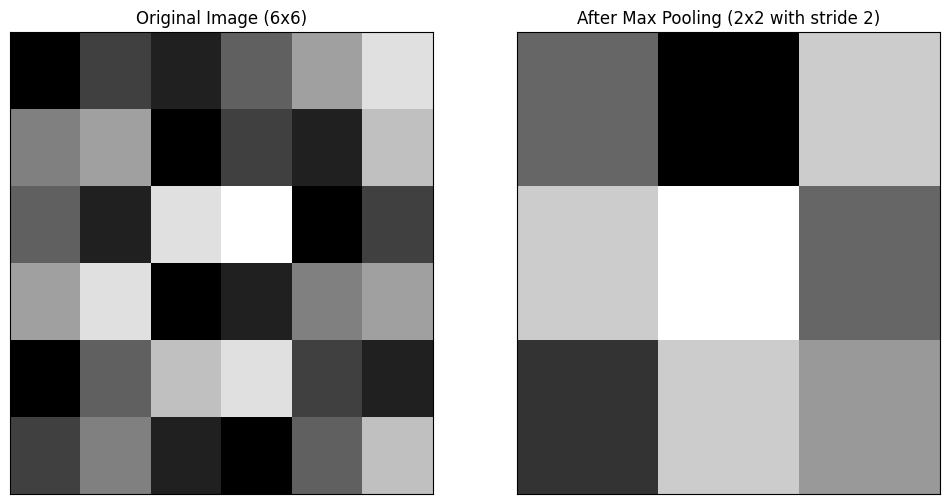

Original Image:
 [[1 3 2 4 6 8]
 [5 6 1 3 2 7]
 [4 2 8 9 1 3]
 [6 8 1 2 5 6]
 [1 4 7 8 3 2]
 [3 5 2 1 4 7]]

Pooled Image (Max Pooling with 2x2 filter and stride 2):
 [[6. 4. 8.]
 [8. 9. 6.]
 [5. 8. 7.]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a simple 6x6 grayscale image (matrix)
image = np.array([
    [1, 3, 2, 4, 6, 8],
    [5, 6, 1, 3, 2, 7],
    [4, 2, 8, 9, 1, 3],
    [6, 8, 1, 2, 5, 6],
    [1, 4, 7, 8, 3, 2],
    [3, 5, 2, 1, 4, 7]
])

# Define the pooling size and stride
pool_size = 2
stride = 2

# Calculate the dimensions of the output after pooling
output_height = (image.shape[0] - pool_size) // stride + 1
output_width = (image.shape[1] - pool_size) // stride + 1

# Initialize the pooled output matrix
pooled_image = np.zeros((output_height, output_width))

# Perform Max Pooling manually
for i in range(output_height):
    for j in range(output_width):
        # Define the current pooling region
        region = image[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
        # Take the maximum value from the current region
        pooled_image[i, j] = np.max(region)

# Display the original image and the pooled image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original image
axes[0].imshow(image, cmap='gray', aspect='auto')
axes[0].set_title('Original Image (6x6)')
axes[0].set_xticks([])
axes[0].set_yticks([])

# Pooled image
axes[1].imshow(pooled_image, cmap='gray', aspect='auto')
axes[1].set_title('After Max Pooling (2x2 with stride 2)')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.show()

# Print the original and pooled image matrices
print("Original Image:\n", image)
print("\nPooled Image (Max Pooling with 2x2 filter and stride 2):\n", pooled_image)


### Question on Max Pooling [4 points]

Given the following 4x4 matrix and a 2x2 Max Pooling filter with a stride of 2, what is the output?

$$
     \text{Matrix} = \begin{bmatrix}
     2 & 4 & 1 & 3 \\
     0 & 6 & 3 & 8 \\
     5 & 1 & 7 & 2 \\
     9 & 2 & 0 & 4
     \end{bmatrix}
$$

Do this step by step rather than with code.

##**Fully Connected Layer**


The **Fully Connected (FC) Layer** is similar to the dense layers used in Multi-Layer Perceptrons (MLPs). It takes the **flattened** feature map (1D vector) as input and produces the final output predictions.


**Intuition:**

- After several convolution and pooling layers, the feature maps have been reduced to a compact, high-level representation of the input image.
- The fully connected layer combines these features to make a final prediction (e.g., classification).

**How It Works:**

1. **Flattening:** The 2D feature map is converted into a 1D vector.
2. **Dense Layers:** The flattened vector is passed through one or more dense layers, where each neuron is connected to every neuron in the previous layer.
3. **Output Layer:** The final layer usually has as many neurons as the number of classes in the classification task. It often uses a **softmax** activation function to produce a probability distribution over the classes.

**Example:**

Suppose the flattened vector is:
$$
\text{Flattened Input} = [0.1, 0.5, 0.3, 0.7]
$$
If we have a dense layer with weights \( W \) and biases \( b \), the output is computed as:
$$
\text{Output} = W \cdot \text{Flattened Input} + b
$$

The final layer might use softmax activation:
$$
\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$
to output a probability for each class.


## Define function to create a convolutional neural network (CNN) model [9 points]

Now we have learned the basic structure of Convolutional Neural Network. In this function, we will create a Convolutional Neural Network (CNN) model suitable for image data.


1. Create a Sequential model.
2. Add a Conv2D layer with 32 filters, kernel size 3x3, ReLU activation, and input shape.
3. Add a MaxPooling2D layer to reduce dimensionality.
4. Repeat Conv2D and MaxPooling2D layers with increasing filter sizes.
5. Flatten the feature maps to create a 1D vector.
6. Add a Dense layer with ReLU activation.
7. Add an output layer with softmax activation for classification.
8. Compile the model using Adam optimizer, categorical crossentropy loss, and accuracy metric.


In [ ]:
def create_cnn_model(input_shape: list[int]) -> tf.keras.Model:
    """
    Create and compile a convolutional neural network (CNN) model.

    Args:
        input_shape (list[int]): The shape of input images.

    Returns:
        tf.keras.Model: Compiled TensorFlow model.

    Detailed Notes:
        This function creates a Convolutional Neural Network (CNN) model with multiple layers:
        1. Input Layer: Takes the shape of the input images as input_shape.
        2. Convolutional and Pooling Layers:
            - First convolutional layer with 32 filters, kernel size 3x3, ReLU activation, followed by MaxPooling.
            - Second convolutional layer with 64 filters, kernel size 3x3, ReLU activation, followed by MaxPooling.
            - Third convolutional layer with 128 filters, kernel size 3x3, ReLU activation, followed by MaxPooling.
        3. Flatten Layer: Flattens the feature maps into a 1D vector.
        4. Dense Layers:
            - First dense layer with 128 units and ReLU activation function.
            - Output layer with 10 units (for 10 classes) and softmax activation for classification.
        The model is compiled using the Adam optimizer, Categorical Crossentropy as the loss function,
        and Accuracy as the evaluation metric.
    """
    # fill code here
    return model

## Train and evaluate the CNN model [6 points]
This function will train the model using the training data and then evaluate its performance on the test data.
1. Train the model using the fit() method with training data, specifying epochs, batch size, and validation split.
2. Evaluate the model on the test data using the evaluate() method.
3. Print the test loss and accuracy.


In [ ]:
# fill code to run the model and print test accuracy.

## Bonus: Can you achieve an accuracy of at least 80% on test set? [5 points]

Briefly explain what you did to get credit.

# Bonus: Support Vector Machines [11 points]

We did not cover Support Vector Machines in class. However, SVMs are still sometimes asked interviews. As such, I am adding this bonus opportunity. SVMs will not be on the quizzes or on the final.

[Recorded Lecture (Need to be logged into NYU)
](https://drive.google.com/file/d/1nkNoo7lThuNV6XZwrLnwTrOet9hj9HOR/view?usp=sharing)

## Part 1 [5 points]

Look at the dataset below. It has two classes and 1 X variable. Propose two feature transformations that wil make the data linearly separable.


Text(0, 0.5, 'Class')

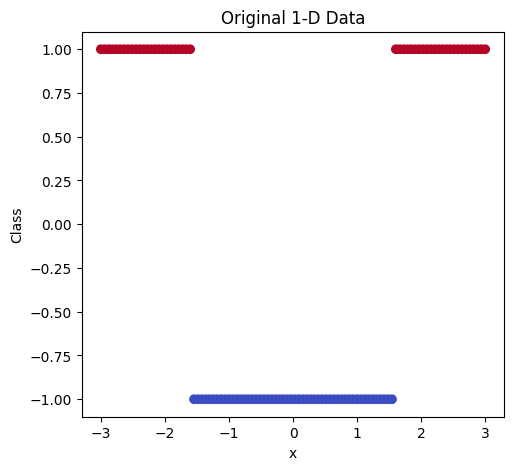

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Generate 1-D dataset
x = np.linspace(-3, 3, 100)
y = np.where(x**2 > 2.5, 1, -1)


# Plot original and transformed data
plt.figure(figsize=(12, 5))

# Original data
plt.subplot(1, 2, 1)
plt.scatter(x, y, c=y, cmap='coolwarm')
plt.title("Original 1-D Data")
plt.xlabel("x")
plt.ylabel("Class")


## Part 2 [6 points]

Show that the distance $d$ of a support vector from the max margin separating hyperplane is $\frac{1}{w}$ where $w^Tx + b = 0$ is the equation of the hyperplane.